# Hong Kong Temperature and Humidity Analysis

本 Notebook 使用香港过去约 50 年的气象数据，分析温度和湿度之间的关系。
数据来源:kaggle.com
https://www.kaggle.com/datasets/hindy51/hong-kong-weather-20082016

主要目标：

1. 读取数据
2. 选择温度和湿度两列
3. 清理缺失值和异常值
4. 绘制散点图
5. 建立简单线性回归模型
6. 计算相关系数和 R²
7. 分析模型效果

In [1]:
#导入模块
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#使所有生成的图都在notebook中显示
%matplotlib inline

In [2]:
#读取datasets
df = pd.read_csv("weather.csv")

In [3]:
#查看csv数据列表的前几行
df.head()


,mean_temp,Grass_Min_Temp,max_Temp,mean_amount_of_cloud,mean_dew_point_temp,mean_wet_bulb_temp,min_temp,pressure,rainfall,RH,date
0,17.7,12.4,20.7,32.0,13.4,15.2,15.5,1018.7,0,77.0,1970-01-01
1,19.5,12.8,22.9,44.0,14.1,16.4,17.2,1018.6,0,72.0,1970-01-02
2,18.8,14.7,21.2,35.0,13.3,15.7,17.5,1019.2,0,71.0,1970-01-03
3,17.9,13.8,20.7,20.0,13.1,15.2,16.1,1020.6,0,74.0,1970-01-04
4,14.7,13.1,18.2,66.0,7.4,11.1,11.8,1026.0,Trace,62.0,1970-01-05


In [4]:
#查看列表栏目
df.columns

Index(['mean_temp', 'Grass_Min_Temp', 'max_Temp', 'mean_amount_of_cloud',
       'mean_dew_point_temp', 'mean_wet_bulb_temp', 'min_temp', 'pressure',
       'rainfall', 'RH', 'date'],
      dtype='object')

In [5]:
#选择我们本次要分析的数据（平均气温和相对湿度），也就是mean_temp和RH
temperature_col = "mean_temp"
humidity_col = "RH"
data = df[[temperature_col, humidity_col]].copy()

data.head()

,mean_temp,RH
0,17.7,77.0
1,19.5,72.0
2,18.8,71.0
3,17.9,74.0
4,14.7,62.0


In [6]:
#有时候可能会需要对数据进行一些清理，但我们这个数据是香港气象局提供的，而且kaggle上的发布者已经有了帮我们清理了数据集，所以这里就不做清理了。
#有些气象数据可能会有空值、缺失符号、文字，所以先把它们转成数字：
data[temperature_col] = pd.to_numeric(data[temperature_col], errors="coerce")
data[humidity_col] = pd.to_numeric(data[humidity_col], errors="coerce")
data.isna().sum()
data = data.dropna()
data.head()


,mean_temp,RH
0,17.7,77.0
1,19.5,72.0
2,18.8,71.0
3,17.9,74.0
4,14.7,62.0


In [7]:
#清理后我们看一下数据里面还有没有什么特别离谱的数据，例如香港的温度一般来说不会是-10，也不太可能大于50.而相对湿度更是只可能在0-100之间
data.describe()


,mean_temp,RH
count,18262.000000,18262.000000
mean,23.273371,78.115048
std,5.157305,10.642117
min,4.900000,24.000000
25%,19.100000,73.000000
50%,24.400000,79.000000
75%,27.800000,85.000000
max,32.400000,99.000000


count：数据数量
mean：平均值
std：标准差
min：最小值
max：最大值

可以看到，最低平均气温是4.9，最高是32，平均是23.是非常正常的数据

相对湿度最低24%，最高99%，平均78%。符合香港的地理气候环境。

在线性回归中，我们通常把自变量设为x，因变量设为y。

这里我们把温度设为x，湿度设为y。

In [8]:
x = data[temperature_col].to_numpy()
y = data[humidity_col].to_numpy()


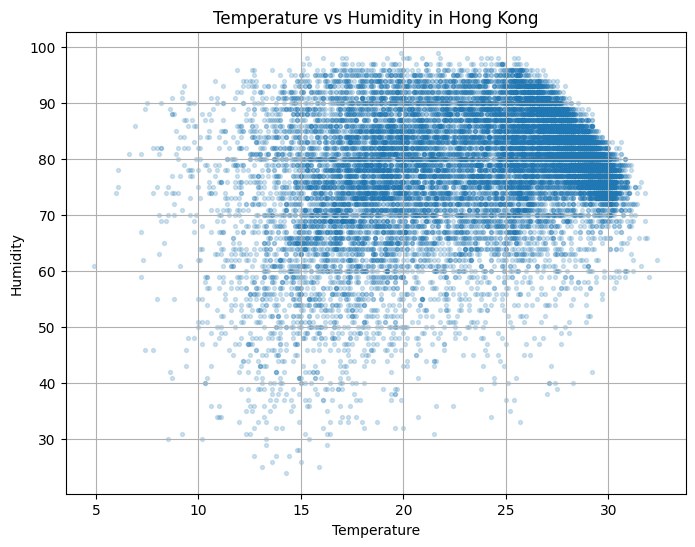

In [9]:
#最基础的散点图
plt.figure(figsize=(8, 6))

plt.scatter(x, y, alpha=0.2, s=8)

plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature vs Humidity in Hong Kong")
plt.grid(True)

plt.show()

#alpha：透明度，越小越透明
#s：点的大小

slope = 0.5330
intercept = 65.7113
R² = 0.0667


/Users/lijunqiang/miniconda3/envs/ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/lijunqiang/miniconda3/envs/ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/lijunqiang/miniconda3/envs/ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28287 (\N{CJK UNIFIED IDEOGRAPH-6E7F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/lijunqiang/miniconda3/envs/ml/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/lijunqiang/miniconda3/envs/ml/lib/python3.11/site-packages/IPytho

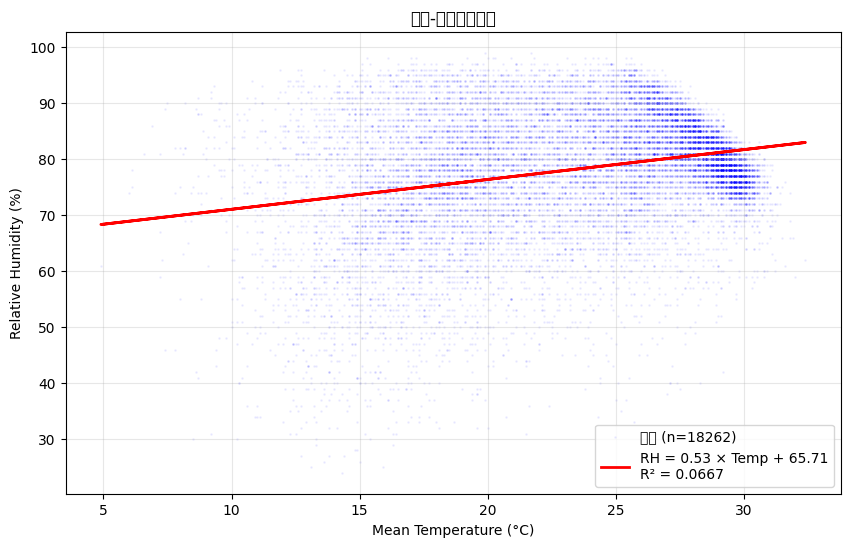

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 清洗数据（你已经做过这一步）
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

# 手动最小二乘拟合
X = np.column_stack([x_clean, np.ones_like(x_clean)])  # 构建设计矩阵
result = np.linalg.lstsq(X, y_clean, rcond=None)
slope, intercept = result[0]  # 第一项是系数

print(f"slope = {slope:.4f}")
print(f"intercept = {intercept:.4f}")

# 计算 R²
y_pred = slope * x_clean + intercept
ss_res = np.sum((y_clean - y_pred) ** 2)
ss_tot = np.sum((y_clean - np.mean(y_clean)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R² = {r_squared:.4f}")

# 可视化
plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, alpha=0.05, s=1, color='blue', label=f'数据 (n={len(x_clean)})')
plt.plot(x_clean, y_pred, color='red', linewidth=2, 
         label=f'RH = {slope:.2f} × Temp + {intercept:.2f}\nR² = {r_squared:.4f}')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('温度-湿度线性回归')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/0z/mrb415h57c71m9y9x61df3r00000gn/T/ipykernel_82144/125387979.py:31: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0z/mrb415h57c71m9y9x61df3r00000gn/T/ipykernel_82144/125387979.py:31: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0z/mrb415h57c71m9y9x61df3r00000gn/T/ipykernel_82144/125387979.py:31: UserWarning: Glyph 28287 (\N{CJK UNIFIED IDEOGRAPH-6E7F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0z/mrb415h57c71m9y9x61df3r00000gn/T/ipykernel_82144/125387979.py:31: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0z/mrb415h57c71m9y9x61df3r00000gn/T/ipykernel_82144/125387979.py:31: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0z/mrb415h57

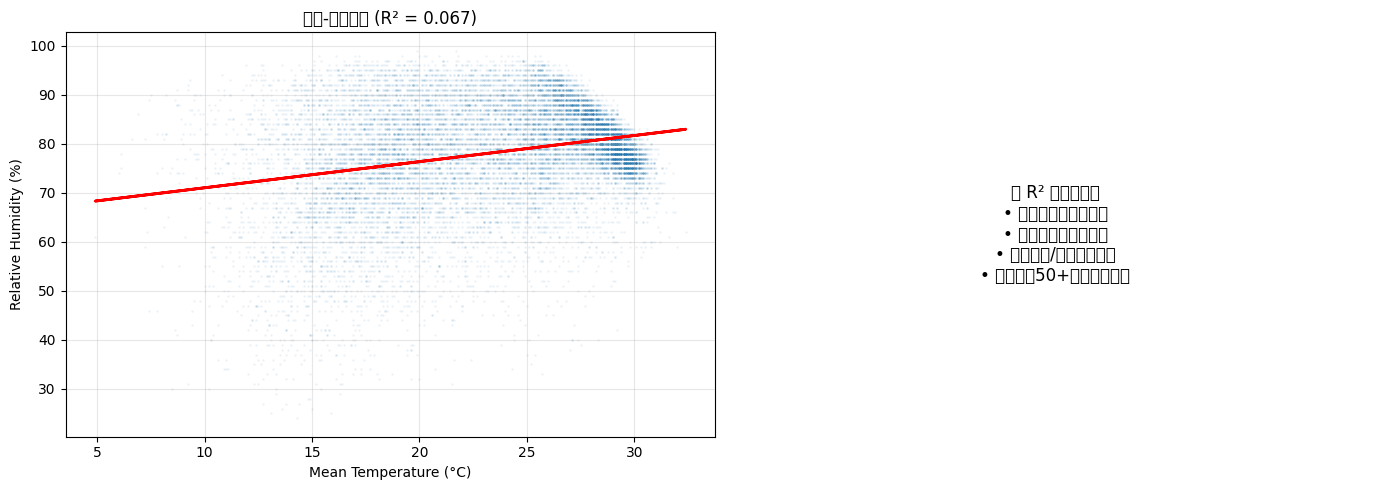

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 清洗数据
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 散点图 + 回归线
axes[0].scatter(x_clean, y_clean, alpha=0.05, s=1)
axes[0].plot(x_clean, 0.5330 * x_clean + 65.7113, 'r-', linewidth=2)
axes[0].set_xlabel('Mean Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title(f'温度-湿度关系 (R² = 0.067)')
axes[0].grid(True, alpha=0.3)

# 相关性热力图提示
axes[1].text(0.5, 0.5, 
             '低 R² 可能原因：\n'
             '• 湿度受多种因素影响\n'
             '• 可能存在非线性关系\n'
             '• 不同季节/天气模式混杂\n'
             '• 数据跨度50+年，气候变化',
             ha='center', va='center', fontsize=12,
             transform=axes[1].transAxes)
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [13]:
import pandas as pd
import numpy as np

# 将 'Trace' 替换为 0（微量降水≈无降水）
df['rainfall'] = df['rainfall'].replace('Trace', 0).astype(float)

# 检查是否还有其他非数值
print("rainfall 数据类型:", df['rainfall'].dtype)
print("rainfall 唯一值样例:", df['rainfall'].unique()[:10])

rainfall 数据类型: float64
rainfall 唯一值样例: [ 0.   7.1  0.7  0.2  0.1 20.4  2.1  0.9  nan  4. ]


各变量与相对湿度的相关性：
RH                      1.000000
mean_amount_of_cloud    0.621367
mean_dew_point_temp     0.604145
mean_wet_bulb_temp      0.472749
rainfall                0.327977
min_temp                0.305791
mean_temp               0.258278
max_Temp                0.191523
pressure               -0.440279
Name: RH, dtype: float64


/var/folders/0z/mrb415h57c71m9y9x61df3r00000gn/T/ipykernel_82144/1092874635.py:29: UserWarning: Glyph 27668 (\N{CJK UNIFIED IDEOGRAPH-6C14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0z/mrb415h57c71m9y9x61df3r00000gn/T/ipykernel_82144/1092874635.py:29: UserWarning: Glyph 35937 (\N{CJK UNIFIED IDEOGRAPH-8C61}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0z/mrb415h57c71m9y9x61df3r00000gn/T/ipykernel_82144/1092874635.py:29: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0z/mrb415h57c71m9y9x61df3r00000gn/T/ipykernel_82144/1092874635.py:29: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0z/mrb415h57c71m9y9x61df3r00000gn/T/ipykernel_82144/1092874635.py:29: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0z/mrb4

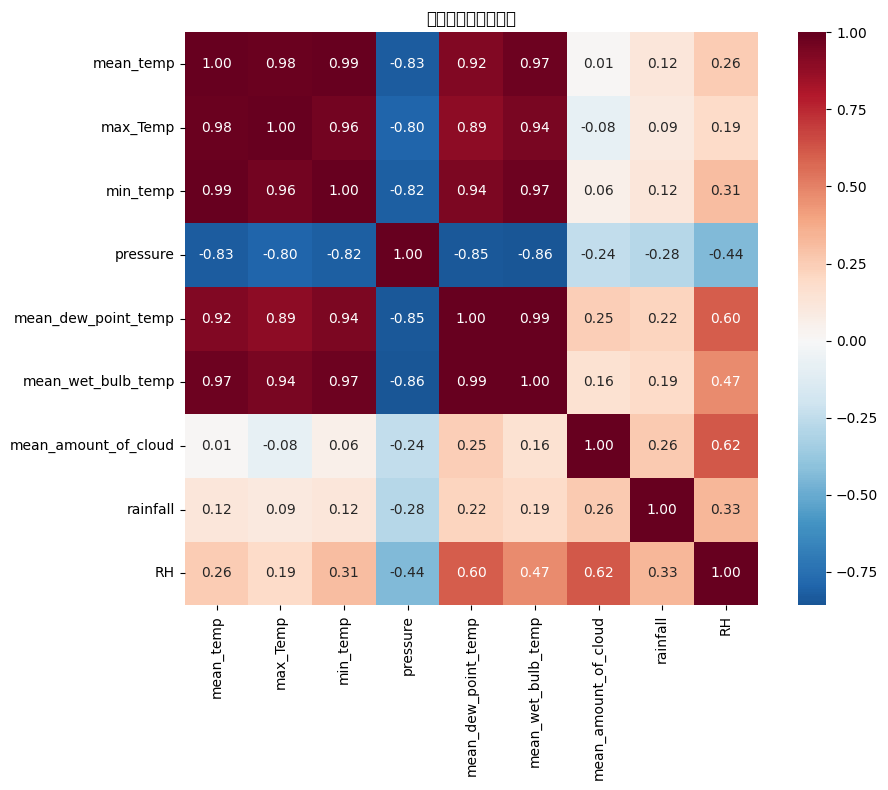


与湿度最相关的变量: mean_amount_of_cloud (r = 0.6214)


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 清洗 rainfall 列
df['rainfall'] = df['rainfall'].replace('Trace', 0).astype(float)

# 2. 确保所有特征列都是数值型
features = ['mean_temp', 'max_Temp', 'min_temp', 'pressure', 
            'mean_dew_point_temp', 'mean_wet_bulb_temp', 
            'mean_amount_of_cloud', 'rainfall']

for col in features:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. 计算相关性
correlations = df[features + ['RH']].corr()['RH'].sort_values(ascending=False)
print("各变量与相对湿度的相关性：")
print(correlations)

# 4. 可视化相关性矩阵
plt.figure(figsize=(10, 8))
corr_matrix = df[features + ['RH']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True)
plt.title('气象变量相关性矩阵')
plt.tight_layout()
plt.show()

# 5. 找出与湿度最相关的变量
top_predictor = correlations.index[1]  # 第0个是RH自身
print(f"\n与湿度最相关的变量: {top_predictor} (r = {correlations[top_predictor]:.4f})")
